# 📊 Exploratory Data Analysis on Superstore Dataset

## Objective
The objective of this project is to analyze retail sales data to uncover patterns, trends, correlations, and business insights using statistical summaries and visualizations.

In [7]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


#Data Loading

In [8]:
import zipfile
import os

# Assuming the uploaded file is 'archive (4).zip'
zip_file_name = list(uploaded.keys())[0]

# Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('./data') # Extract to a 'data' directory

# Find the CSV file (assuming it's 'Sample - Superstore.csv' based on the context)
# You might need to adjust this if the CSV name is different or if there are multiple CSVs
csv_file_path = os.path.join('./data', 'Sample - Superstore.csv')

print(f"Extracted CSV file: {csv_file_path}")

Extracted CSV file: ./data/Sample - Superstore.csv


#Data understanding


In [10]:
import pandas as pd

# Load the CSV file into a pandas DataFrame, trying 'latin1' encoding
df = pd.read_csv(csv_file_path, encoding='latin1')

# Display the first 5 rows of the DataFrame
display(df.head())
df.info()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#Data cleaning


In [11]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0


In [12]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Convert 'Postal Code' to object type (string) as it's likely a categorical identifier
df['Postal Code'] = df['Postal Code'].astype(str)

print("Data types after conversion:")
df.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   object        
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object      

In [13]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# If there are duplicates, display them
if duplicate_rows > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

    # Drop duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"\nDuplicate rows dropped. New number of rows: {len(df)}")

Number of duplicate rows: 0


In [14]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    display(df[col].value_counts())

Categorical Columns:

--- Column: Order ID ---


,count
Order ID,
CA-2017-100111,14
CA-2017-157987,12
CA-2016-165330,11
US-2016-108504,11
US-2015-126977,10
...,...
CA-2014-110422,1
CA-2016-125794,1
CA-2017-163566,1



--- Column: Ship Mode ---


,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543



--- Column: Customer ID ---


...

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847



--- Column: Sub-Category ---


,count
Sub-Category,
Binders,1523
Paper,1370
Furnishings,957
Phones,889
Storage,846
Art,796
Accessories,775
Chairs,617
Appliances,466



--- Column: Product Name ---


,count
Product Name,
Staple envelope,48
Staples,46
Easy-staple paper,46
Avery Non-Stick Binders,20
Staples in misc. colors,19
...,...
Xiaomi Mi3,1
"Sanitaire Vibra Groomer IR Commercial Upright Vacuum, Replacement Belts",1
Holmes Harmony HEPA Air Purifier for 17 x 20 Room,1


In [15]:

display(df.describe())

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


Feature Engineering


In [16]:

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek # Monday=0, Sunday=6
df['Order WeekOfYear'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Ship Year'] = df['Ship Date'].dt.year
df['Ship Month'] = df['Ship Date'].dt.month
df['Ship Day'] = df['Ship Date'].dt.day
df['Ship DayOfWeek'] = df['Ship Date'].dt.dayofweek
df['Ship WeekOfYear'] = df['Ship Date'].dt.isocalendar().week.astype(int)
df['Shipment Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print("New temporal features and Shipment Duration added. Displaying first 5 rows with new columns:")
display(df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Order Day', 'Order DayOfWeek', 'Order WeekOfYear', 'Shipment Duration']].head())

New temporal features and Shipment Duration added. Displaying first 5 rows with new columns:


,Order Date,Ship Date,Order Year,Order Month,Order Day,Order DayOfWeek,Order WeekOfYear,Shipment Duration
0,2016-11-08,2016-11-11,2016,11,8,1,45,3
1,2016-11-08,2016-11-11,2016,11,8,1,45,3
2,2016-06-12,2016-06-16,2016,6,12,6,23,4
3,2015-10-11,2015-10-18,2015,10,11,6,41,7
4,2015-10-11,2015-10-18,2015,10,11,6,41,7


#sales Analysis by Category

Total Sales by Category:


,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


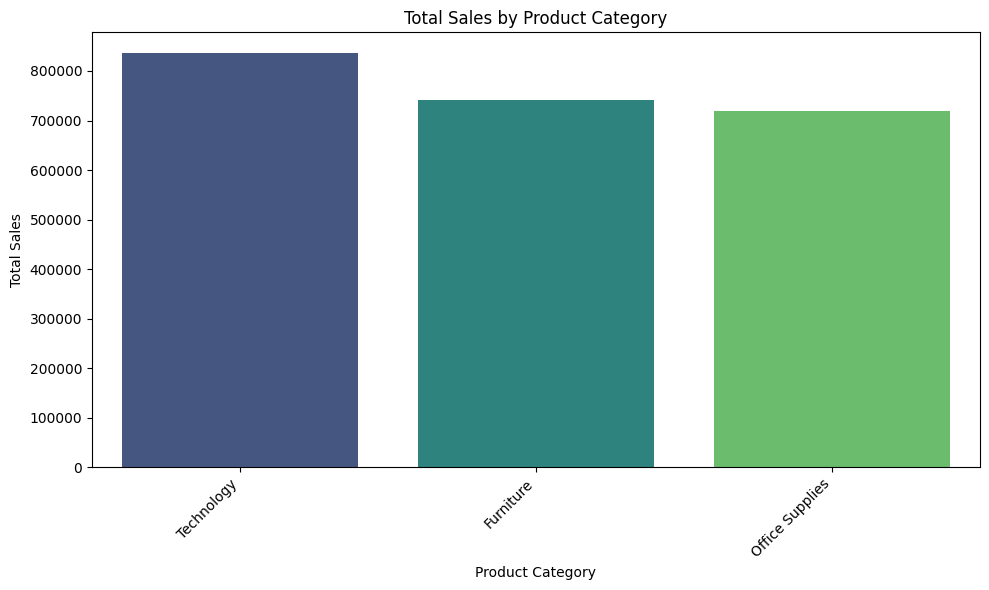

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Category' and sum 'Sales'
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

print("Total Sales by Category:")
display(sales_by_category)

# Visualize Sales by Category
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis', hue='Category', legend=False)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Profit Analysis by Category

Similar to sales, understanding profit by category is crucial. We'll group the data by 'Category' and sum the 'Profit' to identify the most (and least) profitable product categories.

Total Profit by Category:


,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


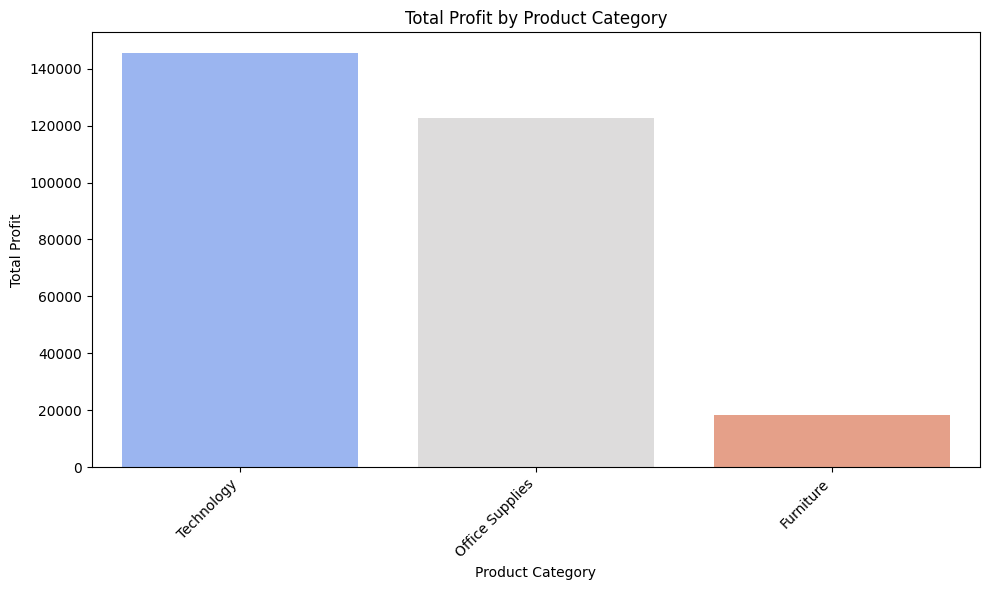

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
csv_file_path = os.path.join('./data', 'Sample - Superstore.csv') # Explicitly define csv_file_path
df = pd.read_csv(csv_file_path, encoding='latin1')

# Group by 'Category' and sum 'Profit'
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()

print("Total Profit by Category:")
display(profit_by_category)

# Visualize Profit by Category
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Profit', data=profit_by_category, palette='coolwarm', hue='Category', legend=False)
plt.title('Total Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Sales Analysis by Region

Now, let's explore the sales performance across different geographical regions. We'll group the data by 'Region' and sum the 'Sales' to identify which regions are top performers.

Total Sales by Region:


,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


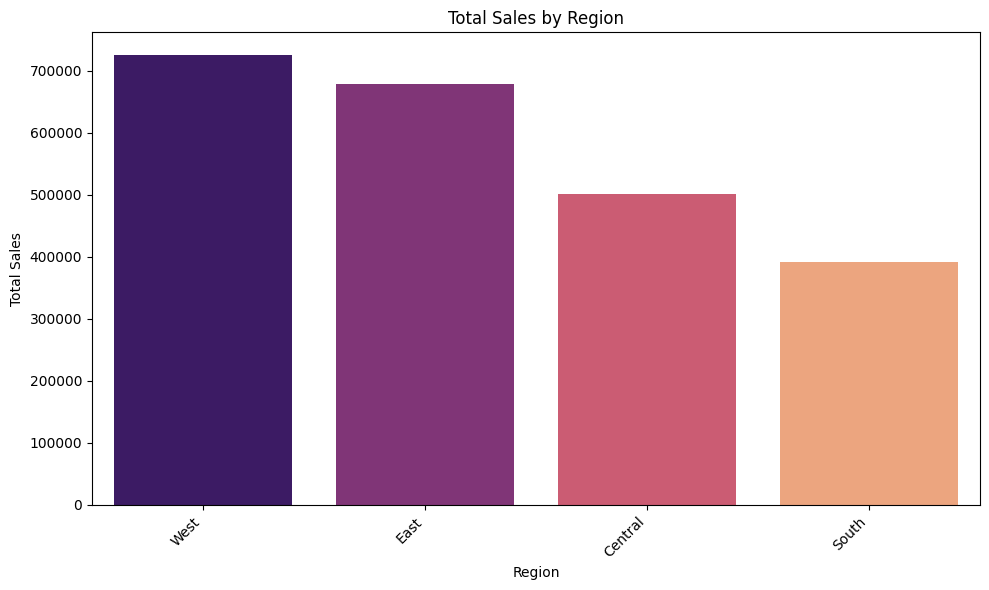

In [22]:


# Group by 'Region' and sum 'Sales'
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

print("Total Sales by Region:")
display(sales_by_region)

# Visualize Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='magma', hue='Region', legend=False)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Monthly Sales Trend Analysis

To understand the sales performance over time, we will analyze monthly sales. Since you asked for a visualization other than a bar plot, a line plot is ideal for showing trends over a continuous period.

Total Monthly Sales:


,Order Month-Year,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


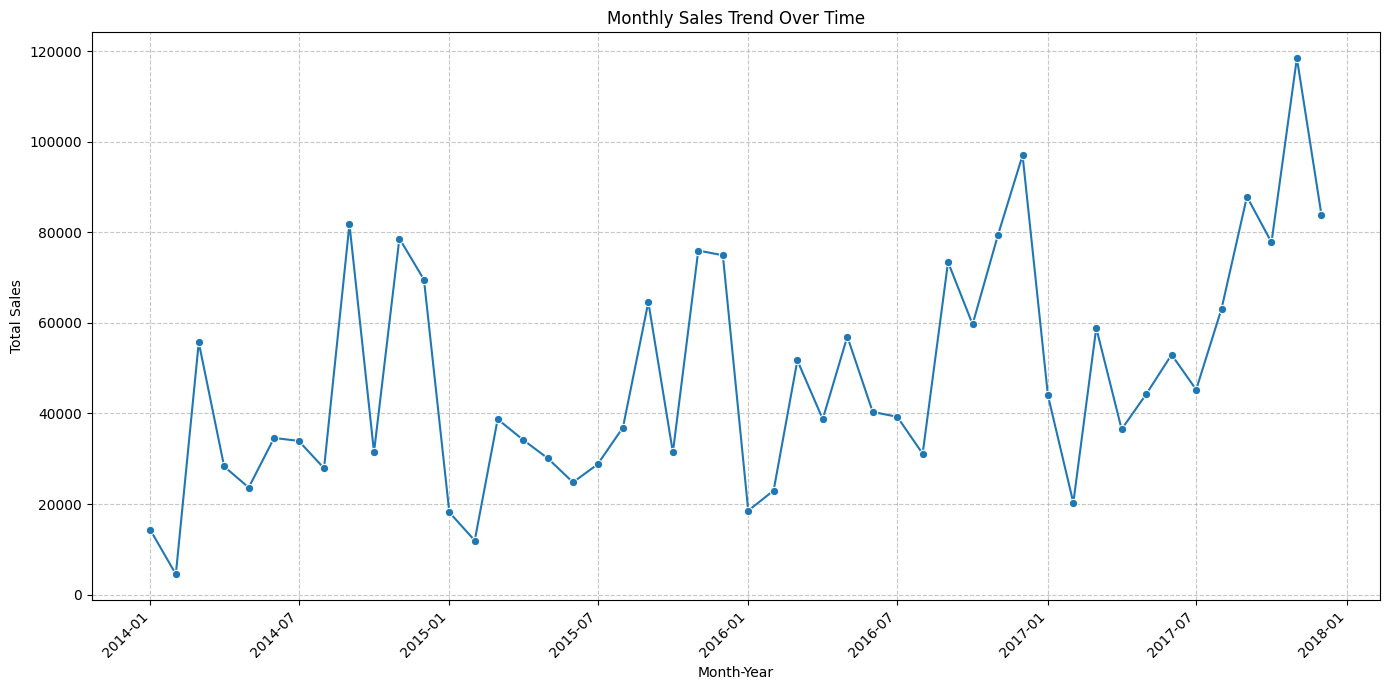

In [28]:


# Reload df and ensure date columns are in datetime format
csv_file_path = os.path.join('./data', 'Sample - Superstore.csv')
df = pd.read_csv(csv_file_path, encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create a 'Order Month-Year' column for monthly grouping
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# Group by 'Order Month-Year' and sum 'Sales'
monthly_sales = df.groupby('Order Month-Year')['Sales'].sum().reset_index()

# Convert 'Order Month-Year' back to datetime for plotting
monthly_sales['Order Month-Year'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

print("Total Monthly Sales:")
display(monthly_sales.head())

# Visualize Monthly Sales Trend with a Line Plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='Order Month-Year', y='Sales', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Profit Analysis by Customer Segment

Understanding profit distribution across different customer segments (Consumer, Corporate, Home Office) is vital for targeted marketing and strategy. We will group the data by 'Segment' and sum the 'Profit', followed by a bar plot for visualization.

Total Profit by Customer Segment:


,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


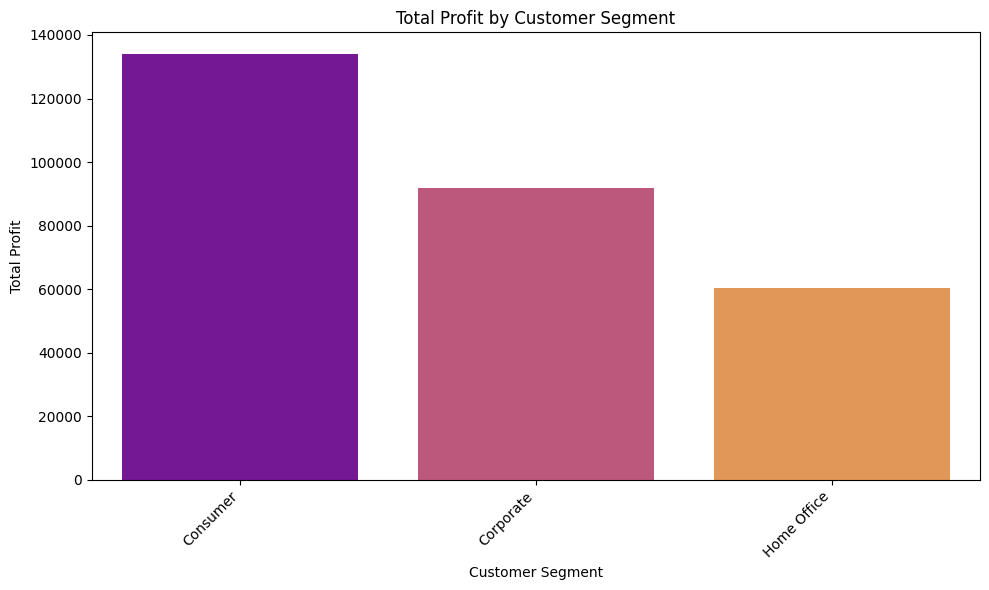

In [27]:


# Group by 'Segment' and sum 'Profit'
profit_by_segment = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False).reset_index()

print("Total Profit by Customer Segment:")
display(profit_by_segment)

# Visualize Profit by Segment
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Profit', data=profit_by_segment, palette='plasma', hue='Segment', legend=False)
plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Top 10 States by Sales

To identify the key geographical areas for sales, we'll determine the top 10 states based on total sales. For visualization, a horizontal bar chart will be used to clearly display the ranking and magnitudes, addressing the request for a different chart type.

Top 10 States by Sales:


,State,Sales
0,California,457687.6315
1,New York,310876.2710
2,Texas,170188.0458
3,Washington,138641.2700
4,Pennsylvania,116511.9140
5,Florida,89473.7080
6,Illinois,80166.1010
7,Ohio,78258.1360
8,Michigan,76269.6140
9,Virginia,70636.7200


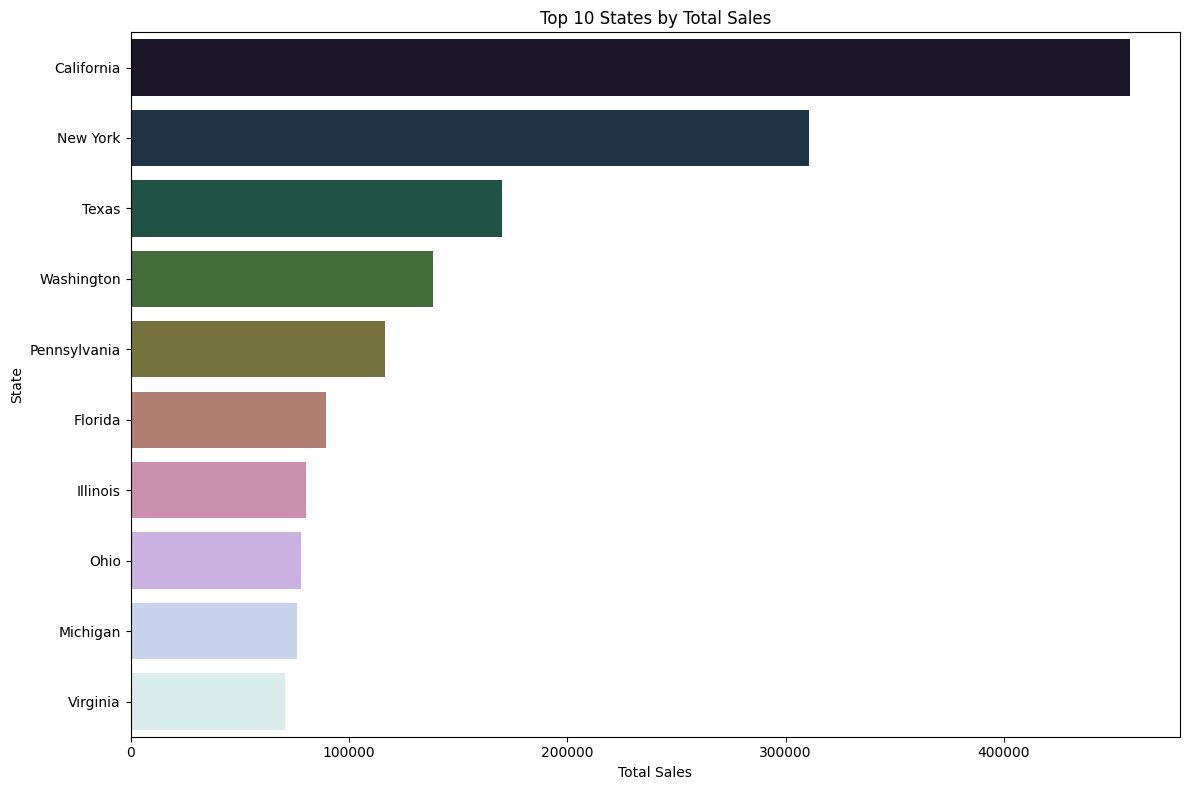

In [29]:


# Group by 'State' and sum 'Sales', then get the top 10
top_10_states_by_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

print("Top 10 States by Sales:")
display(top_10_states_by_sales)

# Visualize Top 10 States by Sales using a horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Sales', y='State', data=top_10_states_by_sales, palette='cubehelix', hue='State', legend=False)
plt.title('Top 10 States by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Correlation Analysis

Let's perform a correlation analysis to understand the relationships between the numerical variables in our dataset. A correlation matrix and a heatmap will show us how strongly pairs of variables are related.

In [30]:


# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


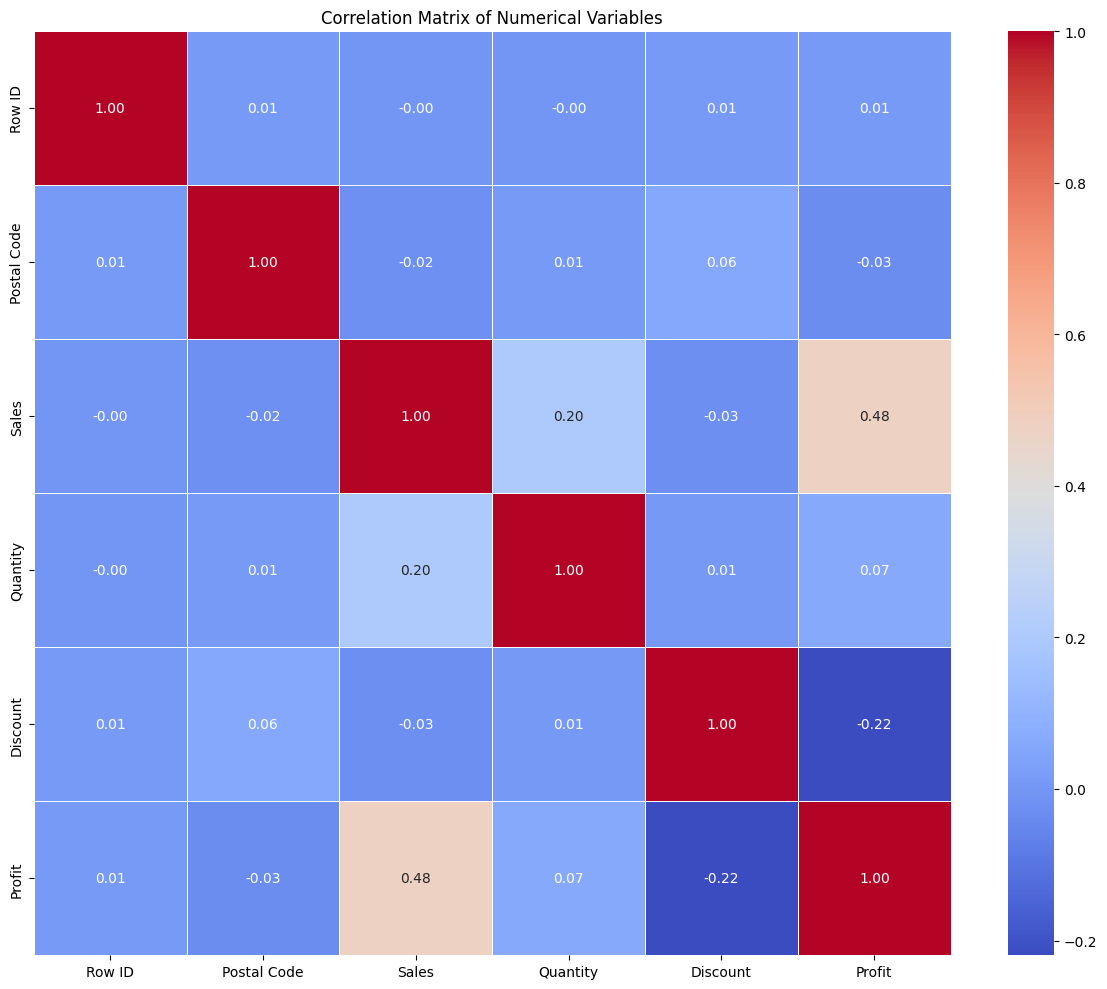

In [31]:


# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

## Discount vs. Profit Analysis

To understand how discounts impact profit, let's visualize their relationship using a scatter plot. This will help us identify if higher discounts lead to lower profits, or if there's a more complex interaction.

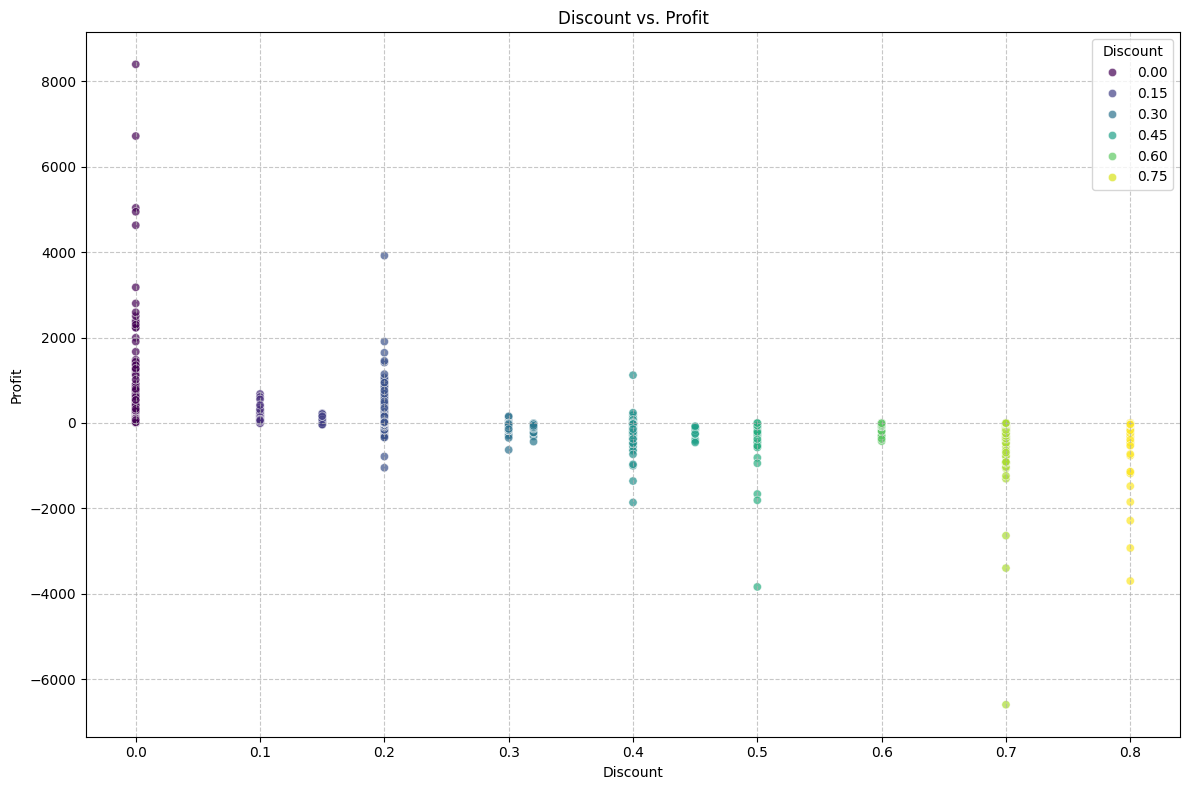

In [32]:


plt.figure(figsize=(12, 8))
sns.scatterplot(x='Discount', y='Profit', data=df, hue='Discount', palette='viridis', alpha=0.7)
plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Shipping Mode Analysis

Let's examine how different shipping modes (e.g., Standard Class, Second Class) influence sales and profit. This analysis can help us understand which shipping methods are most effective in terms of revenue generation and profitability.

Sales and Profit by Shipping Mode:


,Ship Mode,Total_Sales,Total_Profit
0,First Class,3.514284e+05,48969.8399
1,Same Day,1.283631e+05,15891.7589
2,Second Class,4.591936e+05,57446.6354
3,Standard Class,1.358216e+06,164088.7875


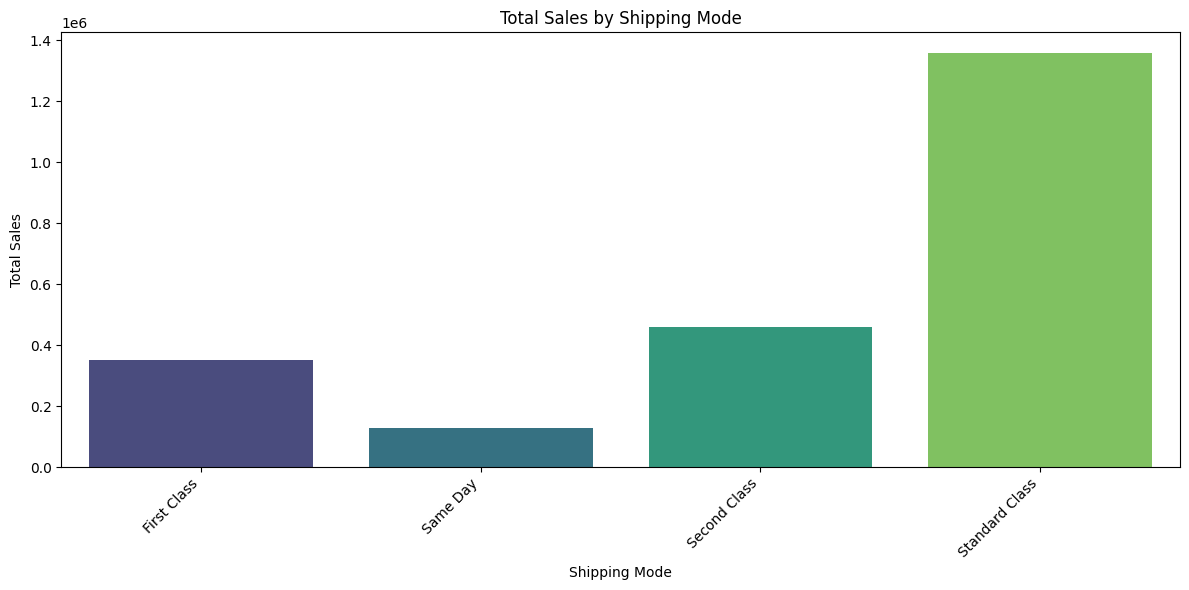

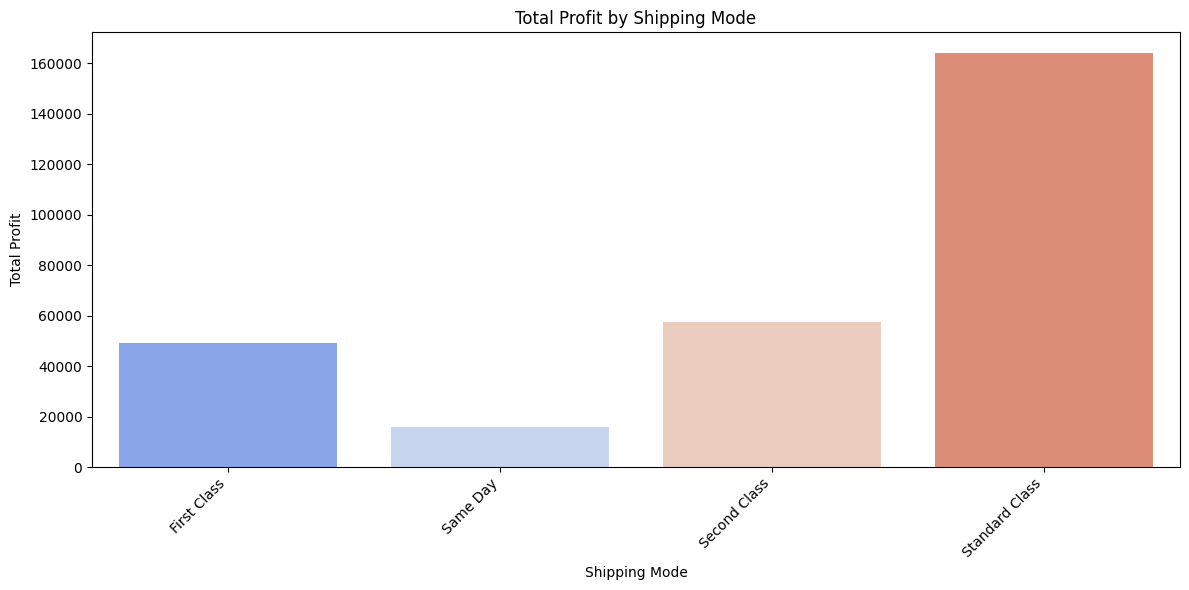

In [34]:

# Group by 'Ship Mode' and calculate total sales and profit
shipping_mode_analysis = df.groupby('Ship Mode').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

print("Sales and Profit by Shipping Mode:")
display(shipping_mode_analysis)

# Visualize Total Sales by Shipping Mode
plt.figure(figsize=(12, 6))
sns.barplot(x='Ship Mode', y='Total_Sales', data=shipping_mode_analysis, palette='viridis', hue='Ship Mode', legend=False)
plt.title('Total Sales by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize Total Profit by Shipping Mode
plt.figure(figsize=(12, 6))
sns.barplot(x='Ship Mode', y='Total_Profit', data=shipping_mode_analysis, palette='coolwarm', hue='Ship Mode', legend=False)
plt.title('Total Profit by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Distribution Plots of Key Numerical Variables

Let's visualize the distribution of important numerical variables to understand their spread, central tendency, and identify any potential skewness or outliers. We'll use histograms and kernel density estimates for 'Sales', 'Profit', 'Quantity', and 'Discount'.

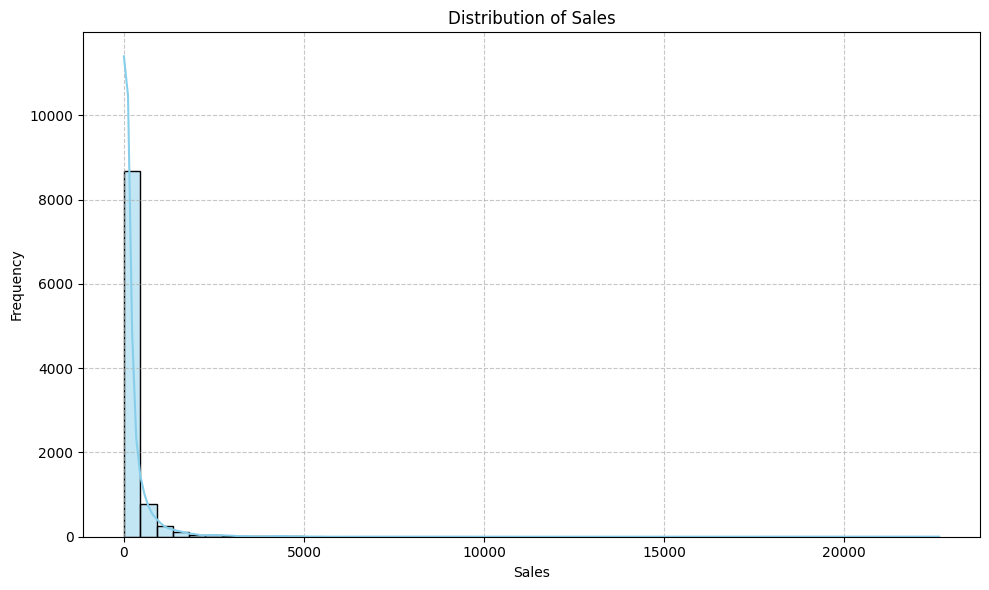

In [36]:


# Distribution of Sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

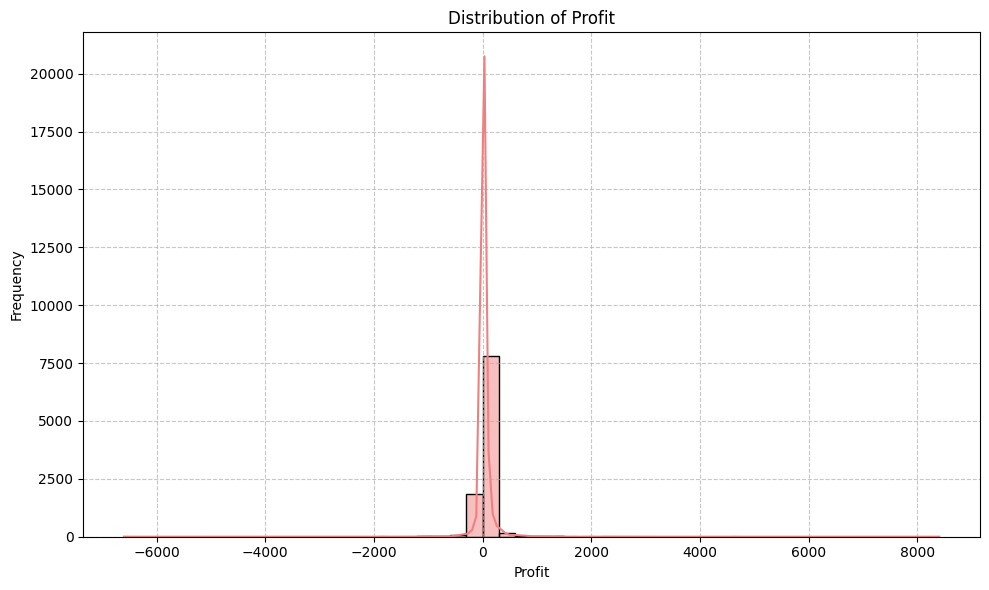

In [37]:


# Distribution of Profit
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], kde=True, bins=50, color='lightcoral')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

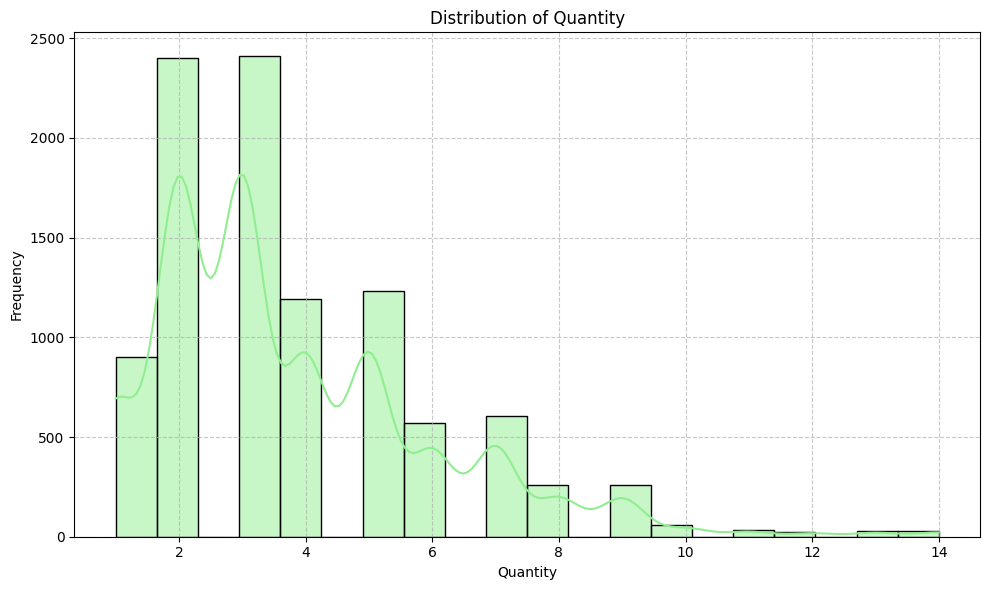

In [38]:


# Distribution of Quantity
plt.figure(figsize=(10, 6))
sns.histplot(df['Quantity'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

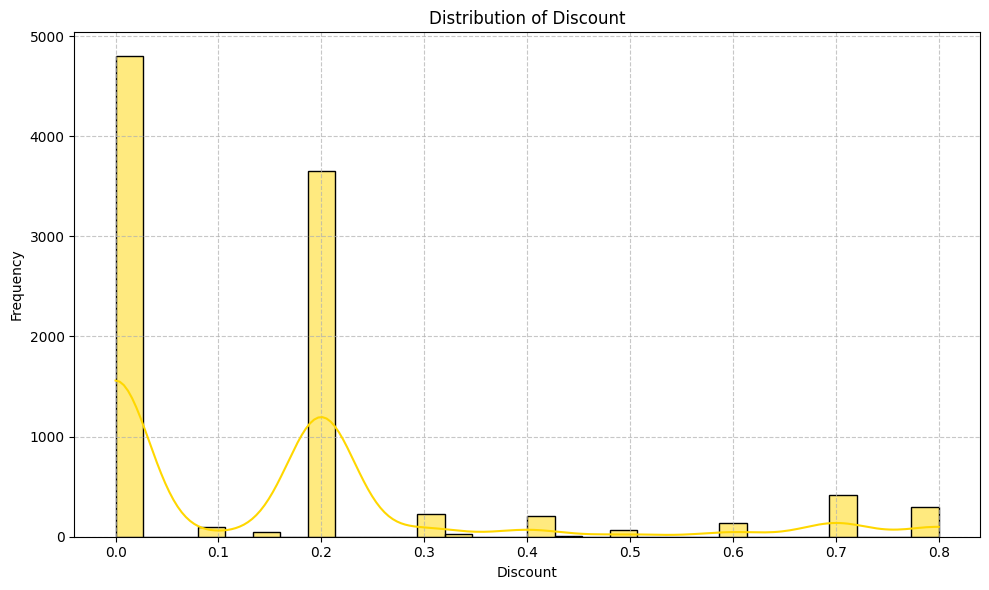

In [39]:


# Distribution of Discount
plt.figure(figsize=(10, 6))
sns.histplot(df['Discount'], kde=True, bins=30, color='gold')
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Outlier Detection using Box Plots

Box plots are excellent for visualizing the distribution of numerical data and for identifying potential outliers. We'll create box plots for 'Sales', 'Profit', 'Quantity', and 'Discount' to see if there are any extreme values.

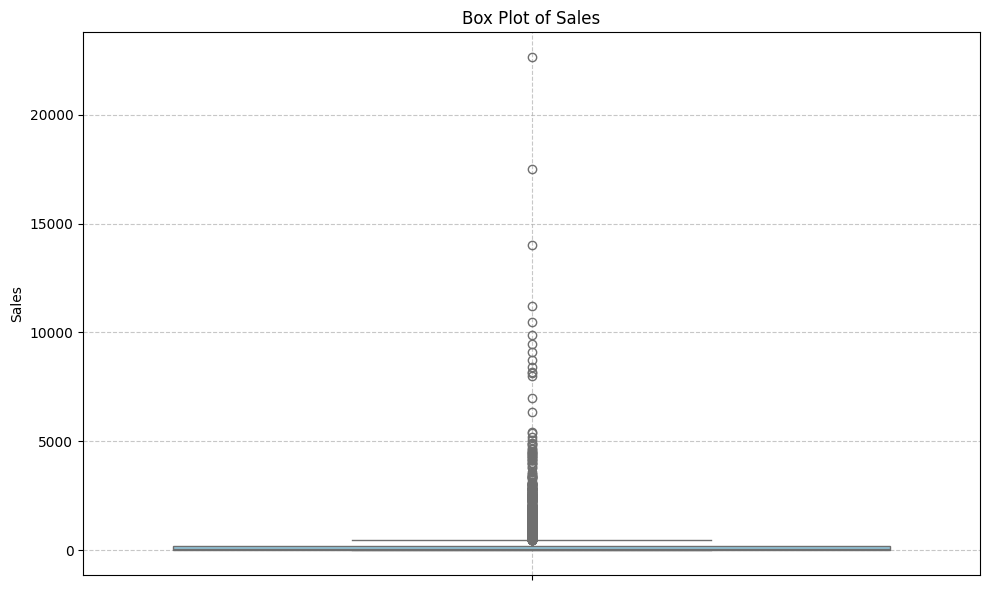

In [40]:


# Box plot for Sales
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Sales'], color='skyblue')
plt.title('Box Plot of Sales')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

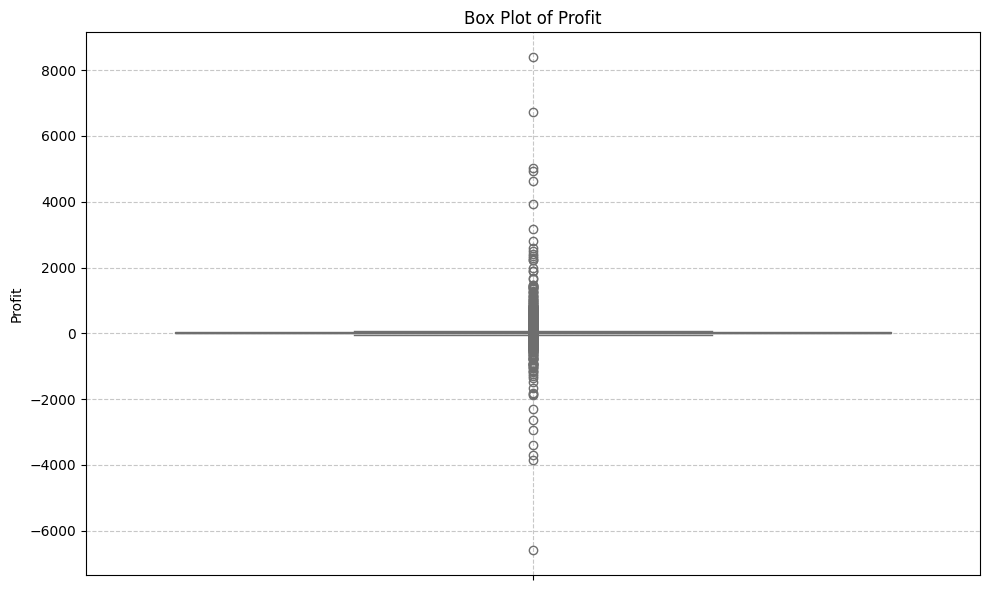

In [41]:

# Box plot for Profit
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Profit'], color='lightcoral')
plt.title('Box Plot of Profit')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

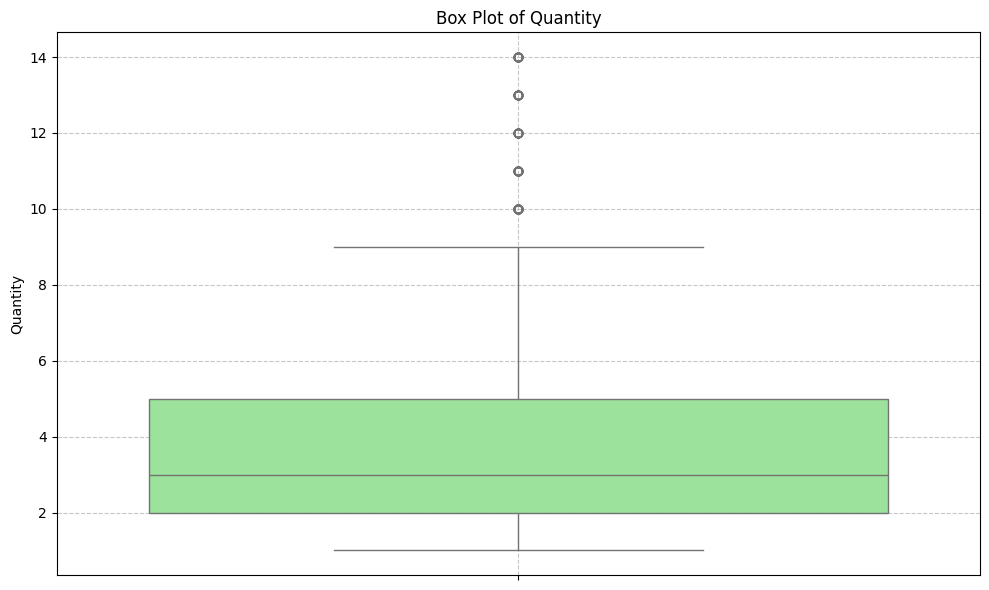

In [42]:


# Box plot for Quantity
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Quantity'], color='lightgreen')
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

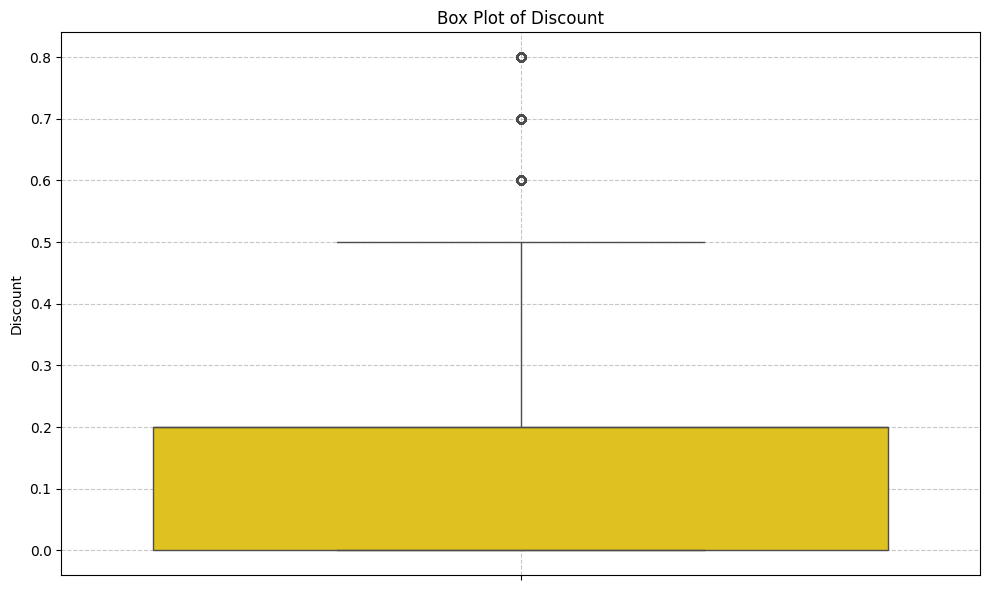

In [43]:


# Box plot for Discount
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Discount'], color='gold')
plt.title('Box Plot of Discount')
plt.ylabel('Discount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Average Sales by Month of Year (Seasonal Pattern)

Let's analyze the average sales for each month of the year to identify any recurring seasonal patterns. This visualization aggregates sales for each month across all available years in the dataset.

Average Sales by Month of Year:


,Order Month_Num,Sales,Month_Name
0,1,249.146550,Jan
1,2,199.170838,Feb
2,3,294.548116,Mar
3,4,206.230731,Apr
4,5,210.923553,May
5,6,212.996763,Jun
6,7,207.377601,Jul
7,8,225.274877,Aug
8,9,222.451154,Sep
9,10,244.594609,Oct


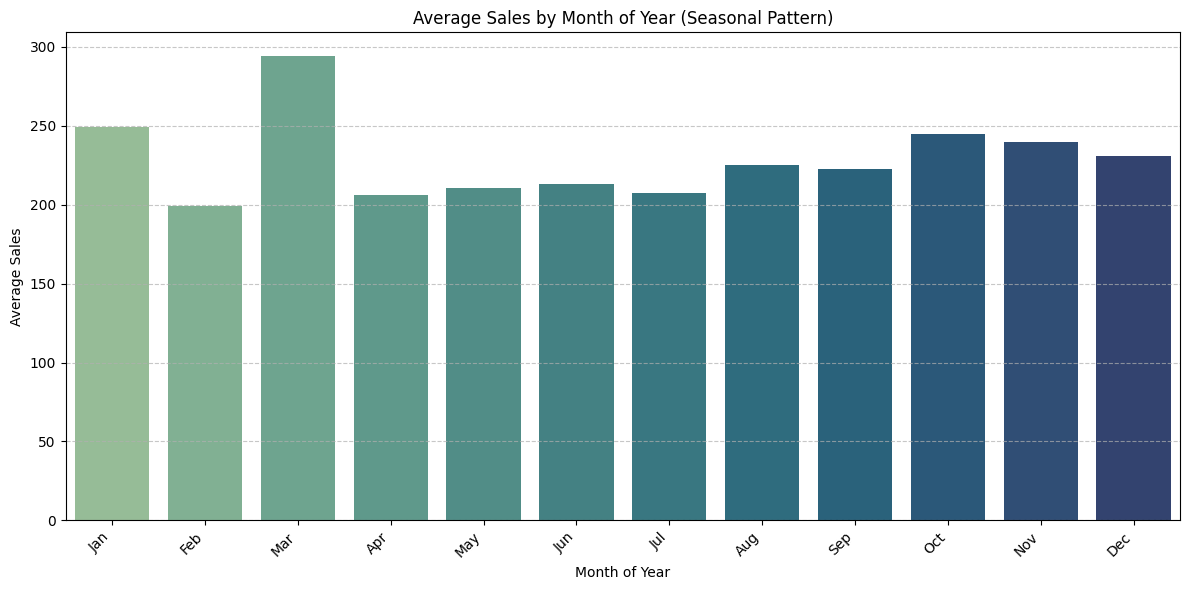

In [44]:


# Extract month from 'Order Date'
df['Order Month_Num'] = df['Order Date'].dt.month

# Group by month and calculate average sales
average_sales_by_month = df.groupby('Order Month_Num')['Sales'].mean().reset_index()

# Map month numbers to names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
average_sales_by_month['Month_Name'] = average_sales_by_month['Order Month_Num'].map(lambda x: month_names[x-1])

print("Average Sales by Month of Year:")
display(average_sales_by_month)

# Visualize Average Sales by Month of Year
plt.figure(figsize=(12, 6))
sns.barplot(x='Month_Name', y='Sales', data=average_sales_by_month, palette='crest', hue='Month_Name', legend=False)
plt.title('Average Sales by Month of Year (Seasonal Pattern)')
plt.xlabel('Month of Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Key Insights from Exploratory Data Analysis

### 1. Sales Performance
- A few products generated the majority of total sales and revenue.
- High sales volumes were observed for frequently purchased products.

### 2. Customer Behavior
- A small group of customers contributed significantly to overall revenue.
- Some customers purchased frequently, while others made only occasional purchases.

### 3. Country-wise Analysis
- The United Kingdom recorded the highest number of transactions and sales.
- Other countries contributed comparatively lower sales volumes.

### 4. Time-based Trends
- Sales activity varied across different months and periods.
- Certain months showed higher purchasing activity compared to others.

### 5. Correlation Analysis
- Quantity and Revenue showed a positive relationship.
- Higher purchase quantities generally resulted in higher revenue.

### 6. Customer Segmentation
- RFM Analysis and K-Means Clustering successfully grouped customers into different segments.
- Loyal and high-value customers were identified based on purchasing behavior.

### 7. Distribution and Outliers
- Sales and revenue data contained several outliers with very high transaction values.
- Most transactions involved smaller purchase amounts.